# **Segment & Risk Index**

## 데이터 불러오기

In [1]:
# 데이터 처리
import numpy as np                          # 수치 계산/벡터·행렬 연산
import pandas as pd                         # 데이터프레임 생성·가공·요약

# 시각화
import matplotlib.pyplot as plt             # 기본 시각화 라이브러리
import seaborn as sns                       # 통계 시각화(분포/관계/범주형 비교) 라이브러리

# 파일 관리
from pathlib import Path                    # 파일 경로 라이브러리

# 출력 설정
from IPython.display import display         # 노트북에서 DataFrame 등을 예쁘게 출력할 때 사용
from tqdm import tqdm                       # for문 진행률 표시 (대용량 반복 작업 시)
pd.set_option('display.max_columns', None)  # 모든 컬럼 다 보이게

# 경고 메시지 제거
import warnings                             # 경고 메시지 제어
warnings.filterwarnings('ignore')           # 불필요한 경고 숨기기 (디버깅 중엔 주석처리 권장)

# KR 한글 설정
!pip install koreanize-matplotlib   
import koreanize_matplotlib                 # Matplotlib 한글 폰트/마이너스 기호 등 자동 설정
plt.rc('font', family='Malgun Gothic')      # 한글 폰트 설정(그래프에서 한글 깨짐 방지)

# 그래프 스타일
sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)
plt.rcParams['figure.dpi'] = 100          # 화면 표시 해상도
plt.rcParams['savefig.dpi'] = 200         # 저장 시 해상도 (더 선명하게)

In [2]:
# 프로젝트 경로 설정
BASE_DIR = Path.cwd().parent

DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"              # 원본 데이터
PROCESSED_DIR = DATA_DIR / "processed"  # 전처리 완료 데이터

OUTPUT_DIR = BASE_DIR / "outputs"     # 그래프, 결과 CSV, 모델 산출물

In [3]:
# 전처리 데이터 불러오기
acc_main = pd.read_csv(PROCESSED_DIR / 'acc_main_preprocessed.csv')
comp_main = pd.read_csv(PROCESSED_DIR / 'comp_main_preprocessed.csv')

print(f"필터링 전: acc_main {acc_main.shape}, comp_main {comp_main.shape}")

필터링 전: acc_main (10142, 16), comp_main (6754, 17)


In [4]:
display(acc_main.head())

,지역,학교급,사고자구분,사고자학년,사고자성별,사고연월,사고발생시각,사고요일,사고시간,사고장소,사고부위,사고형태,사고당시활동,접수연도,사고연월_파싱,사고연도
0,경기,유치원,일반학생,유아,남,2018-04,11:50,금,현장학습,기타 교외,이마,넘어짐,"걷기/뛰기, 오르내리기",2021,2018-04-01,2018
1,광주,초등학교,일반학생,6학년,남,2019-11,10:30,수,현장학습,기타 교외,아래팔,넘어짐,스케이트,2021,2019-11-01,2019
2,인천,고등학교,일반학생,2학년,남,2020-10,14:50,금,현장학습,기타 교외,손,고정된 물체와의 부딪힘,기타,2021,2020-10-01,2020
3,인천,기타학교,일반학생,1학년,남,2020-10,11:00,금,현장학습,기타 교외,무릎,1미터 미만의 높이에서 떨어짐,"(교통수단 등) 운전, 조작, 탑승 중",2021,2020-10-01,2020
4,부산,유치원,일반학생,유아,남,2020-10,11:30,목,현장학습,기타 교외,팔꿈치,1미터 미만의 높이에서 떨어짐,"장난, 놀이",2021,2020-10-01,2020


In [5]:
display(comp_main.head())

,지역,학교급,사고자구분,사고자학년,사고자성별,사고시간,사고장소,사고부위,사고형태,사고당시활동,요양급여,장해급여,간병급여,유족급여,장례비,지급연도,총보상금
0,경기,고등학교,일반학생,1학년,여,"수련활동, 수학여행",운동장,무릎,그밖의 손상 사고,기타,607000,0,0,0,0,2021,607000
1,서울,유치원,일반학생,유아,남,현장학습,기타 교외,턱,1미터 미만의 높이에서 떨어짐,"장난, 놀이",2218000,0,0,0,0,2021,2218000
2,인천,유치원,일반학생,유아,남,현장학습,기타 교외,팔꿈치,고정된 물체와의 부딪힘,기타,91000,0,0,0,0,2021,91000
3,경북,고등학교,일반학생,2학년,여,"수련활동, 수학여행",기타 교외,무릎,넘어짐,"걷기/뛰기, 오르내리기",852000,0,0,0,0,2021,852000
4,대구,초등학교,일반학생,3학년,남,현장학습,기타 체육·집회공간,턱,넘어짐,수영,94000,0,0,0,0,2021,94000


## 분석 범위

- (분류체계개편 이후) 2023 ~ 2025년
- 사고형태 분류체계가 달라 재매핑으로도 완전히 흡수되지 않음

In [6]:
accident_mechanism_map = {
    # 넘어짐·추락
    '넘어짐': '넘어짐·추락',
    '1미터 미만의 높이에서 떨어짐': '넘어짐·추락',
    '1미터 이상의 높이에서 떨어짐': '넘어짐·추락',
    # 사람·물체와 충돌
    '움직이는 물체와의 부딪힘': '사람·물체와 충돌',
    '고정된 물체와의 부딪힘': '사람·물체와 충돌',
    '사람과의 부딪힘': '사람·물체와 충돌',
    # 차량·교통수단 충격
    '교통사고': '차량·교통수단 충격',
    # 신체동작·염좌·과긴장
    '이동 중 충격을 가함': '신체동작·염좌·과긴장',
    '스포츠 활동 중 충격을 가함': '신체동작·염좌·과긴장',
    '물건을 운반하는 중 충격을 가함': '신체동작·염좌·과긴장',
    # 끼임·베임·찔림
    '물체 사이에 끼임·눌림': '끼임·베임·찔림',
    '사람 사이에 끼임·눌림': '끼임·베임·찔림',
    '긁힘, 찔림': '끼임·베임·찔림',
    '베임, 절단': '끼임·베임·찔림',
    # 온도·화학·환경노출
    '동물에게 물림(사람 포함)': '온도·화학·환경노출',
    '곤충·식물 등에 쏘임': '온도·화학·환경노출',
    '고온의 물체·물질 접촉·흡입·섭취': '온도·화학·환경노출',
    '일사병, 열사병': '온도·화학·환경노출',
    '추위에 장시간 노출': '온도·화학·환경노출',
    '저온의 물체(드라이아이스 등)·물질 접촉': '온도·화학·환경노출',
    '화학물질 접촉·흡입·섭취': '온도·화학·환경노출',
    '이물질 접촉에 의한 피부염': '온도·화학·환경노출',
    # 익수·질식·질환
    '기타 호흡 곤란': '익수·질식·질환',
    '식중독': '익수·질식·질환',
    '이물질 섭취로 인한 질병': '익수·질식·질환',
    '이물질에 의한 질식': '익수·질식·질환',
    # 기타·불명
    '그밖의 손상 사고': '기타·불명',
}

acc_main['사고기전'] = acc_main['사고형태'].map(accident_mechanism_map)

unmapped = acc_main[acc_main['사고기전'].isnull()]['사고형태'].unique()
print("매핑 안 된 사고형태:", unmapped)
print()
print(acc_main['사고기전'].value_counts())

매핑 안 된 사고형태: []

사고기전
넘어짐·추락         4108
사람·물체와 충돌      2493
신체동작·염좌·과긴장    1551
끼임·베임·찔림        742
기타·불명           692
온도·화학·환경노출      369
익수·질식·질환        168
차량·교통수단 충격       19
Name: count, dtype: int64


시기구분,개편 전,개편 후
사고기전,,
기타·불명,8.31,6.26
끼임·베임·찔림,5.05,8.18
넘어짐·추락,60.08,33.07
사람·물체와 충돌,21.34,25.81
신체동작·염좌·과긴장,0.00,21.10
온도·화학·환경노출,3.83,3.57
익수·질식·질환,1.07,1.88
차량·교통수단 충격,0.32,0.14


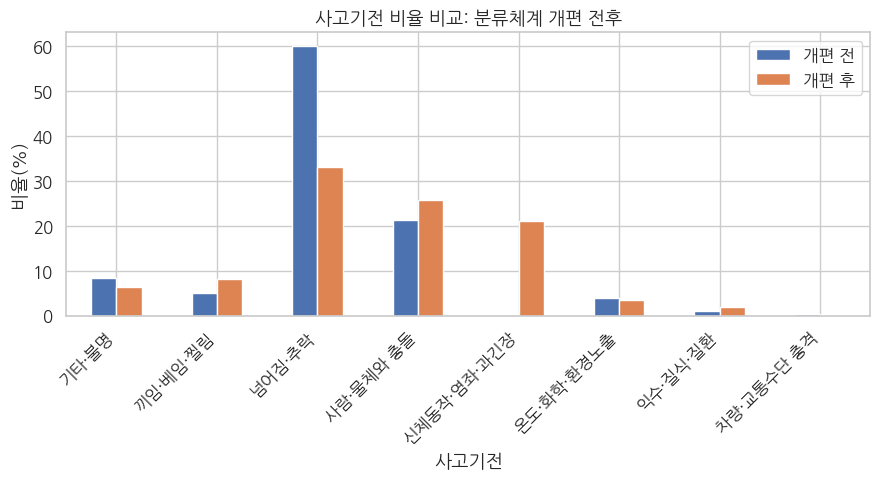

In [7]:
# 개편 이전 vs 이후(2023-2025) 사고기전 비율 비교
acc_main['시기구분'] = acc_main['사고연도'].apply(lambda y: '개편 전' if y <= 2022 else '개편 후')

mechanism_by_period = pd.crosstab(
    acc_main['사고기전'], acc_main['시기구분'], normalize='columns'
) * 100

mechanism_by_period = mechanism_by_period.round(2)
display(mechanism_by_period)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(9, 5))
mechanism_by_period.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_ylabel('비율(%)')
ax.set_title('사고기전 비율 비교: 분류체계 개편 전후')
ax.legend(title='')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
# 2023~2025년 데이터 필터링
acc_main = acc_main[acc_main['사고연도'].isin([2023, 2024, 2025])].reset_index(drop=True)
comp_main = comp_main[comp_main['지급연도'].isin([2023, 2024, 2025])].reset_index(drop=True)

print(f"필터링 후: acc_main {acc_main.shape}, comp_main {comp_main.shape}")

필터링 후: acc_main (7349, 18), comp_main (5165, 17)


## 컬럼 정리

- 지역, 사고자성별, 사고자학년 삭제

In [9]:
drop_cols_acc = [c for c in ['지역', '사고자성별', '사고자학년'] if c in acc_main.columns]
drop_cols_comp = [c for c in ['지역', '사고자성별', '사고자학년'] if c in comp_main.columns]

acc_main = acc_main.drop(columns=drop_cols_acc)
comp_main = comp_main.drop(columns=drop_cols_comp)

print(f"acc_main: {acc_main.shape}")
print(f"comp_main: {comp_main.shape}")
print()
print("acc_main 컬럼:", acc_main.columns.tolist())
print("comp_main 컬럼:", comp_main.columns.tolist())

acc_main: (7349, 15)
comp_main: (5165, 14)

acc_main 컬럼: ['학교급', '사고자구분', '사고연월', '사고발생시각', '사고요일', '사고시간', '사고장소', '사고부위', '사고형태', '사고당시활동', '접수연도', '사고연월_파싱', '사고연도', '사고기전', '시기구분']
comp_main 컬럼: ['학교급', '사고자구분', '사고시간', '사고장소', '사고부위', '사고형태', '사고당시활동', '요양급여', '장해급여', '간병급여', '유족급여', '장례비', '지급연도', '총보상금']


## 사고기전 매핑

- 사고형태 기준
- 고용노동부 재해발생형태 분류체계 기반

In [10]:
accident_mechanism_map = {
    '넘어짐': '넘어짐·추락',
    '1미터 미만의 높이에서 떨어짐': '넘어짐·추락',
    '1미터 이상의 높이에서 떨어짐': '넘어짐·추락',
    '움직이는 물체와의 부딪힘': '사람·물체와 충돌',
    '고정된 물체와의 부딪힘': '사람·물체와 충돌',
    '사람과의 부딪힘': '사람·물체와 충돌',
    '교통사고': '차량·교통수단 충격',
    '이동 중 충격을 가함': '신체동작·염좌·과긴장',
    '스포츠 활동 중 충격을 가함': '신체동작·염좌·과긴장',
    '물건을 운반하는 중 충격을 가함': '신체동작·염좌·과긴장',
    '물체 사이에 끼임·눌림': '끼임·베임·찔림',
    '사람 사이에 끼임·눌림': '끼임·베임·찔림',
    '긁힘, 찔림': '끼임·베임·찔림',
    '베임, 절단': '끼임·베임·찔림',
    '동물에게 물림(사람 포함)': '온도·화학·환경노출',
    '곤충·식물 등에 쏘임': '온도·화학·환경노출',
    '고온의 물체·물질 접촉·흡입·섭취': '온도·화학·환경노출',
    '일사병, 열사병': '온도·화학·환경노출',
    '추위에 장시간 노출': '온도·화학·환경노출',
    '저온의 물체(드라이아이스 등)·물질 접촉': '온도·화학·환경노출',
    '화학물질 접촉·흡입·섭취': '온도·화학·환경노출',
    '이물질 접촉에 의한 피부염': '온도·화학·환경노출',
    '기타 호흡 곤란': '익수·질식·질환',
    '식중독': '익수·질식·질환',
    '이물질 섭취로 인한 질병': '익수·질식·질환',
    '이물질에 의한 질식': '익수·질식·질환',
    '그밖의 손상 사고': '기타·불명',
}

acc_main['사고기전'] = acc_main['사고형태'].map(accident_mechanism_map)
comp_main['사고기전'] = comp_main['사고형태'].map(accident_mechanism_map)

print(acc_main['사고기전'].isnull().sum(), "건 매핑 안 됨")
print(acc_main['사고기전'].value_counts())

0 건 매핑 안 됨
사고기전
넘어짐·추락         2430
사람·물체와 충돌      1897
신체동작·염좌·과긴장    1551
끼임·베임·찔림        601
기타·불명           460
온도·화학·환경노출      262
익수·질식·질환        138
차량·교통수단 충격       10
Name: count, dtype: int64


## 사고상황 매핑

### 1순위 - 사고당시활동

In [11]:
# 1순위: 사고당시활동만으로 판정 가능한 값들
situation_map_primary = {
    # 교통수단 이동·승하차
    '(교통수단 등) 운전, 조작, 탑승 중': '교통수단 이동·승하차',

    # 관람·학습체험
    '수업': '관람·학습체험',
    '자습': '관람·학습체험',
    '과학실험': '관람·학습체험',
    '일반실습': '관람·학습체험',

    # 스포츠·놀이
    '축구': '스포츠·놀이', '농구': '스포츠·놀이', '배구': '스포츠·놀이',
    '야구': '스포츠·놀이', '피구': '스포츠·놀이', '족구': '스포츠·놀이',
    '배드민턴': '스포츠·놀이', '테니스': '스포츠·놀이', '탁구': '스포츠·놀이',
    '골프': '스포츠·놀이', '볼링': '스포츠·놀이', '양궁·사격': '스포츠·놀이',
    '인라인/롤러 스케이트': '스포츠·놀이', '스케이트 보드': '스포츠·놀이',
    '사이클': '스포츠·놀이', '기타 바퀴달린 무동력 스포츠': '스포츠·놀이',
    '달리기': '스포츠·놀이', '뜀뛰기': '스포츠·놀이', '던지기': '스포츠·놀이',
    '태권도·유도·합기도': '스포츠·놀이', '검도·펜싱': '스포츠·놀이',
    '레슬링': '스포츠·놀이', '씨름': '스포츠·놀이', '복싱·킥복싱': '스포츠·놀이',
    '리듬·기계체조': '스포츠·놀이', '매트운동': '스포츠·놀이',
    '무용(댄스 포함)': '스포츠·놀이', '기타 스포츠 활동': '스포츠·놀이',
    '장난, 놀이': '스포츠·놀이',
    '기타 육상': '스포츠·놀이', '기타 구기': '스포츠·놀이', '장애물': '스포츠·놀이',
    '기타 타겟형 스포츠': '스포츠·놀이', '태권도, 유도, 합기도': '스포츠·놀이',
    '뉴스포츠(구기)': '스포츠·놀이', '기타 무도': '스포츠·놀이',
    '뉴스포츠(타켓형)': '스포츠·놀이', '기타 라켓 스포츠': '스포츠·놀이',
    '뉴스포츠(던지기)': '스포츠·놀이',

    # 자연·수상·전문활동
    '전공실습': '자연·수상·전문활동', '수영': '자연·수상·전문활동',
    '다이빙': '자연·수상·전문활동', '기타 수중 스포츠': '자연·수상·전문활동',
    '스키·스노우보드': '자연·수상·전문활동', '스케이트': '자연·수상·전문활동',
    '아이스하키': '자연·수상·전문활동', '기타 설상·빙상': '자연·수상·전문활동',
    '기타 설상, 빙상': '자연·수상·전문활동',

    # 식사·숙박·생활
    '식사': '식사·숙박·생활', '씻기': '식사·숙박·생활', '수면': '식사·숙박·생활',

    # 기타·불명
    '싸움': '기타·불명','기타': '기타·불명',
    '기타 일상활동': '기타·불명',
}

acc_main['사고상황'] = acc_main['사고당시활동'].map(situation_map_primary)

print("1차 매핑 후 미매핑 건수:", acc_main['사고상황'].isnull().sum())
print(acc_main[acc_main['사고상황'].isnull()]['사고당시활동'].value_counts())

1차 매핑 후 미매핑 건수: 2447
사고당시활동
걷기/뛰기, 오르내리기    1924
휴식               523
Name: count, dtype: int64


### 2순위 - 사고장소

In [12]:
# 2순위: 사고당시활동이 모호한 경우(휴식·걷기·기타·기타일상), 사고장소로 판정
# * 청소년 수련 시설은 장소명만으로 활동 성격이 특정되지 않는 복합공간
location_to_situation = {
    # 집결·대기
    '계단': '집결·대기', '기타 교내': '집결·대기', '기타 공용공간': '집결·대기',
    '현관': '집결·대기', '복도': '집결·대기',

    # 교통수단 이동·승하차
    '교통구역(스쿨존 외)-인도': '교통수단 이동·승하차',
    '교통구역(스쿨존 내)-인도': '교통수단 이동·승하차',
    '교통구역(스쿨존 외)-기타 교통구역': '교통수단 이동·승하차',
    '교통구역(스쿨존 내)-기타 교통구역': '교통수단 이동·승하차',
    '교통구역(스쿨존 외)-교통수단 안': '교통수단 이동·승하차',
    '교통구역(스쿨존 외)-차도': '교통수단 이동·승하차',
    '교통구역(스쿨존 내)-교통수단 안': '교통수단 이동·승하차',
    '교통구역(스쿨존 내)-차도': '교통수단 이동·승하차',
    '교통구역(스쿨존 외)-자전거도로': '교통수단 이동·승하차',
    '교통구역(스쿨존 내)-자전거도로': '교통수단 이동·승하차',

    # 관람·학습체험
    '전시관, 체험관': '관람·학습체험', '문화유적지': '관람·학습체험',
    '영화관, 공연장': '관람·학습체험', '학습지원공간': '관람·학습체험',
    '일반(교과)교실': '관람·학습체험', '특별교실(과학실 외)': '관람·학습체험',

    # 스포츠·놀이
    '공원, 유원 시설': '스포츠·놀이', '어린이 놀이시설': '스포츠·놀이',
    '기타 문화·체육공간': '스포츠·놀이', '실·내외 체육시설': '스포츠·놀이',
    '운동장': '스포츠·놀이', '강당(체육관)': '스포츠·놀이',
    '기타 체육·집회공간': '스포츠·놀이', '놀이터': '스포츠·놀이',
    '청소년 수련 시설': '스포츠·놀이',

    # 자연·수상·전문활동
    '산림·계곡': '자연·수상·전문활동', '기타 자연': '자연·수상·전문활동',
    '강·바다·하천': '자연·수상·전문활동', '현장실습/근로지(직업계고)': '자연·수상·전문활동',

    # 식사·숙박·생활
    '숙박시설/식당': '식사·숙박·생활', '화장실': '식사·숙박·생활',

    # 기타·불명
    '기타 교외': '기타·불명',
    '청소년 수련 시설': '기타·불명',
}

mask_unmapped = acc_main['사고상황'].isnull()
acc_main.loc[mask_unmapped, '사고상황'] = acc_main.loc[mask_unmapped, '사고장소'].map(location_to_situation)

print("2차 매핑 후 남은 미매핑 건수:", acc_main['사고상황'].isnull().sum())
print(acc_main[acc_main['사고상황'].isnull()]['사고장소'].value_counts())
print(acc_main['사고상황'].value_counts())

2차 매핑 후 남은 미매핑 건수: 0
Series([], Name: count, dtype: int64)
사고상황
스포츠·놀이         2916
기타·불명          1746
자연·수상·전문활동      930
관람·학습체험         657
식사·숙박·생활        582
교통수단 이동·승하차     468
집결·대기            50
Name: count, dtype: int64


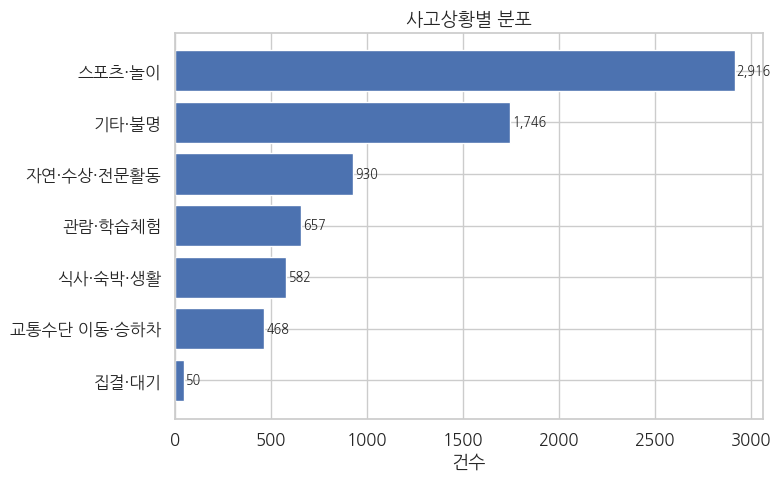

In [13]:
# 사고상황별 분포
fig, ax = plt.subplots(figsize=(8, 5))
situation_counts = acc_main['사고상황'].value_counts()
ax.barh(situation_counts.index, situation_counts.values, color='#4C72B0')
ax.invert_yaxis()
ax.set_xlabel('건수')
ax.set_title('사고상황별 분포')

for i, v in enumerate(situation_counts.values):
    ax.text(v + 10, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### [참고] 기타·불명 분해 시도 - 사고발생시각

- 사고장소가 '청소년 수련시설'인 사고를 세분화해보려하였으나, 유의미한 결과 확인 X

In [14]:
# 기타·불명으로 들어간 것들이 어떤 경로로 들어왔는지 분해
etc_cases = acc_main[acc_main['사고상황'] == '기타·불명']

print("경로별 구성")
print(etc_cases['사고당시활동'].value_counts())
print()
print("경로별 사고장소")
print(etc_cases[etc_cases['사고당시활동'].isin(['걷기/뛰기, 오르내리기', '휴식'])]['사고장소'].value_counts())

경로별 구성
사고당시활동
기타              923
걷기/뛰기, 오르내리기    342
기타 일상활동         277
휴식              202
싸움                2
Name: count, dtype: int64

경로별 사고장소
사고장소
청소년 수련 시설    385
기타 교외        159
Name: count, dtype: int64


In [15]:
# 사고발생시각 타입 변환
def parse_hour(time_str):
    try:
        hour = int(str(time_str).split(':')[0])
        if 0 <= hour <= 23:
            return hour
        else:
            return None
    except (ValueError, AttributeError):
        return None

acc_main['사고발생시_숫자'] = acc_main['사고발생시각'].apply(parse_hour)

print("파싱 실패(결측 포함) 건수:", acc_main['사고발생시_숫자'].isnull().sum())
print(acc_main['사고발생시_숫자'].describe())

파싱 실패(결측 포함) 건수: 0
count    7349.000000
mean       13.094435
std         3.716668
min         0.000000
25%        11.000000
50%        12.000000
75%        15.000000
max        23.000000
Name: 사고발생시_숫자, dtype: float64


시간대
오후(12-17시)    155
저녁(18-23시)    129
오전(6-11시)      92
새벽(0-5시)        9
Name: count, dtype: int64


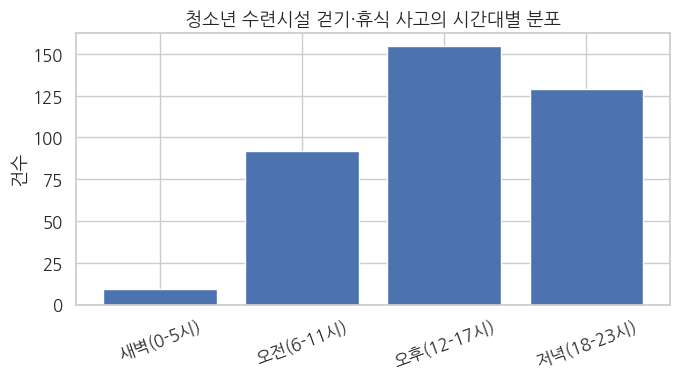

In [16]:
# 시간대 구간화
youth_ambiguous = acc_main[
    (acc_main['사고장소'] == '청소년 수련 시설') &
    (acc_main['사고당시활동'].isin(['걷기/뛰기, 오르내리기', '휴식']))
].copy()

youth_ambiguous['시간대'] = pd.cut(
    youth_ambiguous['사고발생시_숫자'],
    bins=[-1, 5, 11, 17, 23],
    labels=['새벽(0-5시)', '오전(6-11시)', '오후(12-17시)', '저녁(18-23시)']
)

print(youth_ambiguous['시간대'].value_counts())

fig, ax = plt.subplots(figsize=(7, 4))
time_counts = youth_ambiguous['시간대'].value_counts().sort_index()
ax.bar(time_counts.index.astype(str), time_counts.values, color='#4C72B0')
ax.set_title('청소년 수련시설 걷기·휴식 사고의 시간대별 분포')
ax.set_ylabel('건수')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [17]:
# 청소년 수련 시설 교차표
cross_time_activity = pd.crosstab(youth_ambiguous['시간대'], youth_ambiguous['사고당시활동'])
display(cross_time_activity)

사고당시활동,"걷기/뛰기, 오르내리기",휴식
시간대,,
새벽(0-5시),1,8
오전(6-11시),63,29
오후(12-17시),91,64
저녁(18-23시),49,80


### comp_main 매핑

In [18]:
# comp_main에 사고기전 매핑
comp_main['사고기전'] = comp_main['사고형태'].map(accident_mechanism_map)

# comp_main에 사고상황 매핑
comp_main['사고상황'] = comp_main['사고당시활동'].map(situation_map_primary)

mask_unmapped_comp = comp_main['사고상황'].isnull()
comp_main.loc[mask_unmapped_comp, '사고상황'] = comp_main.loc[mask_unmapped_comp, '사고장소'].map(location_to_situation)

comp_main['사고상황'] = comp_main['사고상황'].fillna('기타·불명')

print("acc_main 사고기전 미매핑:", acc_main['사고기전'].isnull().sum())
print("comp_main 사고기전 미매핑:", comp_main['사고기전'].isnull().sum())
print()
print("comp_main 사고상황 분포")
print(comp_main['사고상황'].value_counts())

acc_main 사고기전 미매핑: 0
comp_main 사고기전 미매핑: 0

comp_main 사고상황 분포
사고상황
스포츠·놀이         2002
기타·불명          1317
자연·수상·전문활동      662
관람·학습체험         440
식사·숙박·생활        374
교통수단 이동·승하차     333
집결·대기            37
Name: count, dtype: int64


## 최종 세그먼트 결합 - 사고상황 × 사고기전

In [19]:
acc_main['세그먼트'] = acc_main['사고상황'] + ' × ' + acc_main['사고기전']
comp_main['세그먼트'] = comp_main['사고상황'] + ' × ' + comp_main['사고기전']

print("2차원 세그먼트 종류 수:", acc_main['세그먼트'].nunique())
print(acc_main['세그먼트'].value_counts())

2차원 세그먼트 종류 수: 49
세그먼트
스포츠·놀이 × 넘어짐·추락              960
스포츠·놀이 × 사람·물체와 충돌           866
스포츠·놀이 × 신체동작·염좌·과긴장         752
기타·불명 × 넘어짐·추락               476
기타·불명 × 사람·물체와 충돌            460
자연·수상·전문활동 × 넘어짐·추락          410
기타·불명 × 신체동작·염좌·과긴장          275
관람·학습체험 × 넘어짐·추락             239
자연·수상·전문활동 × 신체동작·염좌·과긴장     237
기타·불명 × 기타·불명                193
스포츠·놀이 × 끼임·베임·찔림            186
교통수단 이동·승하차 × 넘어짐·추락         186
기타·불명 × 끼임·베임·찔림             166
자연·수상·전문활동 × 사람·물체와 충돌       160
식사·숙박·생활 × 사람·물체와 충돌         156
관람·학습체험 × 사람·물체와 충돌          152
식사·숙박·생활 × 넘어짐·추락            136
관람·학습체험 × 신체동작·염좌·과긴장        123
스포츠·놀이 × 기타·불명               104
기타·불명 × 익수·질식·질환              93
교통수단 이동·승하차 × 사람·물체와 충돌       93
교통수단 이동·승하차 × 신체동작·염좌·과긴장     86
기타·불명 × 온도·화학·환경노출            83
식사·숙박·생활 × 끼임·베임·찔림           81
관람·학습체험 × 끼임·베임·찔림            69
식사·숙박·생활 × 신체동작·염좌·과긴장        66
식사·숙박·생활 × 온도·화학·환경노출         66
식사·숙박·생활 × 기타·불명              56
자연·수상·전문활동 × 끼임·베임·찔림         52
관람·학습체험 × 온도·화학·환경노출

In [20]:
# 세그먼트별 표본 크기만 확인
segment_acc_count = acc_main.groupby('세그먼트').size().reset_index(name='사고건수')
segment_comp_count = comp_main.groupby('세그먼트').size().reset_index(name='보상건수')

segment_combined = segment_acc_count.merge(segment_comp_count, on='세그먼트', how='inner')
assert len(segment_combined) == len(segment_acc_count), "acc_main 기준 세그먼트 누락 발생"

def classify_reliability(n):
    if n >= 30:
        return '본분석'
    elif n >= 10:
        return '탐색적'
    else:
        return '제외'

segment_combined['신뢰도구분'] = segment_combined['보상건수'].apply(classify_reliability)
segment_main = segment_combined[segment_combined['신뢰도구분'] == '본분석'][['세그먼트', '사고건수', '보상건수']].copy()

print(f"본분석 대상: {len(segment_main)}개")

본분석 대상: 31개


In [21]:
# [참고] 보상데이터에만 있고 사고데이터에는 없는 세그먼트
comp_segments = set(comp_main['세그먼트'].unique())
acc_segments = set(acc_main['세그먼트'].unique())

only_in_comp = comp_segments - acc_segments
print("comp_main에만 있고 acc_main에는 없는 세그먼트:", only_in_comp)

comp_main에만 있고 acc_main에는 없는 세그먼트: {'기타·불명 × 차량·교통수단 충격'}


In [23]:
segment_combined = segment_acc_count.merge(segment_comp_count, on='세그먼트', how='inner')

# inner join 기준: acc_main(사고건수)이 기준 축이므로 combined는 acc_count와 같아야 함
assert len(segment_combined) == len(segment_acc_count), \
    f"acc_main 기준 세그먼트가 누락됨: acc={len(segment_acc_count)}, combined={len(segment_combined)}"

dropped = len(segment_comp_count) - len(segment_combined)
print(f"comp_main에만 있어 분석에서 제외된 세그먼트: {dropped}개")

def classify_reliability(n):
    if n >= 30:
        return '본분석'
    elif n >= 10:
        return '탐색적'
    else:
        return '제외'

segment_combined['신뢰도구분'] = segment_combined['보상건수'].apply(classify_reliability)

segment_main = segment_combined[segment_combined['신뢰도구분'] == '본분석'].copy()
segment_exploratory = segment_combined[segment_combined['신뢰도구분'] == '탐색적'].copy()

total_accidents = segment_combined['사고건수'].sum()
main_accidents = segment_main['사고건수'].sum()

print(f"본분석 대상 세그먼트: {len(segment_main)}개")
print(f"탐색적 대상 세그먼트: {len(segment_exploratory)}개")
print(f"제외된 세그먼트: {len(segment_combined) - len(segment_main) - len(segment_exploratory)}개")
print(f"본분석 대상 사고건수 포괄률: {main_accidents/total_accidents*100:.1f}%")

comp_main에만 있어 분석에서 제외된 세그먼트: 1개
본분석 대상 세그먼트: 31개
탐색적 대상 세그먼트: 6개
제외된 세그먼트: 12개
본분석 대상 사고건수 포괄률: 96.4%


## 지수 계산

### **발생비중 (F)**

- 발생비중 = 해당 세그먼트 사고건수 / 전체 사고건수 * 100

In [36]:
from scipy.stats import skew

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# [참고] 로그변환 필요성
segment_main['건수_log'] = np.log1p(segment_main['사고건수'])

raw_skew = skew(segment_main['사고건수'])
log_skew = skew(segment_main['건수_log'])

print(f"원본 사고건수 왜도: {raw_skew:.2f}")
print(f"로그변환 후 왜도: {log_skew:.2f}")

원본 사고건수 왜도: 1.90
로그변환 후 왜도: 0.62


In [ ]:
# [참고] 세그먼트별 사고건수 추세 확인
year_counts = acc_main.groupby(['세그먼트', '사고연도']).size().unstack(fill_value=0)
year_counts = year_counts.reindex(segment_main['세그먼트'])

# 두 구간의 증감 방향 확인
change_1 = year_counts[2024] - year_counts[2023]
change_2 = year_counts[2025] - year_counts[2024]

def classify_trend(c1, c2):
    if c1 > 0 and c2 > 0:
        return '꾸준히 증가'
    elif c1 < 0 and c2 < 0:
        return '꾸준히 감소'
    elif c1 == 0 and c2 == 0:
        return '변화 없음'
    else:
        return '들쭉날쭉'

trend = pd.DataFrame({
    '세그먼트': year_counts.index,
    '2023': year_counts[2023].values,
    '2024': year_counts[2024].values,
    '2025': year_counts[2025].values,
    '구간1_변화': change_1.values,
    '구간2_변화': change_2.values,
})
trend['추세'] = trend.apply(lambda row: classify_trend(row['구간1_변화'], row['구간2_변화']), axis=1)

print(trend['추세'].value_counts())
print()
display(trend.sort_values('사고건수' if '사고건수' in trend.columns else '2025', ascending=False))

추세
들쭉날쭉      20
꾸준히 감소    10
꾸준히 증가     1
Name: count, dtype: int64



,세그먼트,2023,2024,2025,구간1_변화,구간2_변화,추세
17,스포츠·놀이 × 넘어짐·추락,355,329,276,-26,-53,꾸준히 감소
18,스포츠·놀이 × 사람·물체와 충돌,271,330,265,59,-65,들쭉날쭉
19,스포츠·놀이 × 신체동작·염좌·과긴장,260,248,244,-12,-4,꾸준히 감소
10,기타·불명 × 넘어짐·추락,156,179,141,23,-38,들쭉날쭉
11,기타·불명 × 사람·물체와 충돌,153,168,139,15,-29,들쭉날쭉
28,자연·수상·전문활동 × 넘어짐·추락,155,136,119,-19,-17,꾸준히 감소
12,기타·불명 × 신체동작·염좌·과긴장,96,94,85,-2,-9,꾸준히 감소
14,기타·불명 × 익수·질식·질환,8,2,83,-6,81,들쭉날쭉
30,자연·수상·전문활동 × 신체동작·염좌·과긴장,79,81,77,2,-4,들쭉날쭉
16,스포츠·놀이 × 끼임·베임·찔림,63,56,67,-7,11,들쭉날쭉


In [ ]:
# [참고] 세그먼트별 사고건수 추세 비율
print("추세 분포가 한쪽으로 쏠려있지 않은지 확인")
print(trend['추세'].value_counts(normalize=True).round(3) * 100, "%")

추세 분포가 한쪽으로 쏠려있지 않은지 확인
추세
들쭉날쭉      64.5
꾸준히 감소    32.3
꾸준히 증가     3.2
Name: proportion, dtype: float64 %


In [ ]:
# 발생비중 계산
total_all_segments = acc_main['세그먼트'].value_counts().sum()
segment_main['발생비중'] = (segment_main['사고건수'] / total_all_segments * 100).round(2)

display(segment_main[['세그먼트', '사고건수', '발생비중']].sort_values('발생비중', ascending=False))

,세그먼트,사고건수,발생비중
24,스포츠·놀이 × 넘어짐·추락,960,13.06
25,스포츠·놀이 × 사람·물체와 충돌,866,11.78
26,스포츠·놀이 × 신체동작·염좌·과긴장,752,10.23
17,기타·불명 × 넘어짐·추락,476,6.48
18,기타·불명 × 사람·물체와 충돌,460,6.26
39,자연·수상·전문활동 × 넘어짐·추락,410,5.58
19,기타·불명 × 신체동작·염좌·과긴장,275,3.74
2,관람·학습체험 × 넘어짐·추락,239,3.25
41,자연·수상·전문활동 × 신체동작·염좌·과긴장,237,3.22
15,기타·불명 × 기타·불명,193,2.63


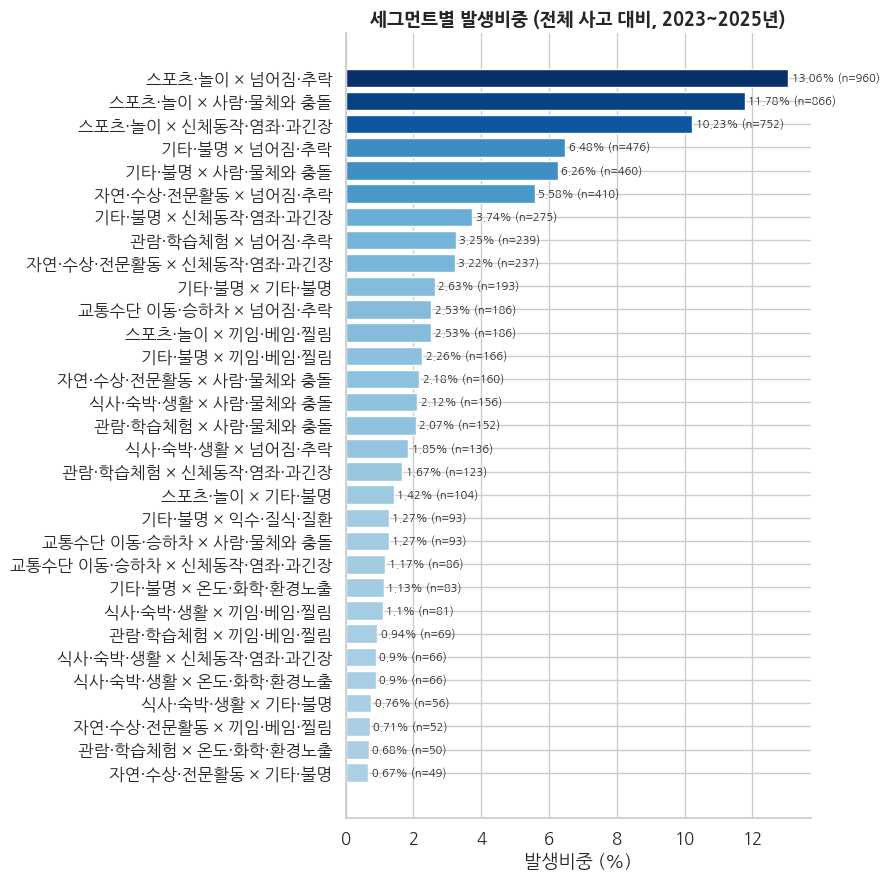

In [ ]:
# 세그먼트별 발생비중 그래프
fig, ax = plt.subplots(figsize=(9, 9))

plot_data = segment_main.sort_values('발생비중')
colors = plt.cm.Blues(plot_data['발생비중'] / plot_data['발생비중'].max() * 0.7 + 0.3)

bars = ax.barh(plot_data['세그먼트'], plot_data['발생비중'], color=colors)
ax.set_xlabel('발생비중 (%)')
ax.set_title('세그먼트별 발생비중 (전체 사고 대비, 2023~2025년)', fontsize=13, fontweight='bold')

for i, (pct, count) in enumerate(zip(plot_data['발생비중'], plot_data['사고건수'])):
    ax.text(pct + 0.1, i, f'{pct}% (n={count})', va='center', fontsize=8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# [참고] 세그먼트별 연도별 건수 표
year_breakdown = acc_main.groupby(['세그먼트', '사고연도']).size().unstack(fill_value=0)
year_breakdown.columns = [f'{y}년' for y in year_breakdown.columns]

segment_main = segment_main.merge(year_breakdown, on='세그먼트', how='left')

display(
    segment_main[['세그먼트', '발생비중', '2023년', '2024년', '2025년']]
    .sort_values('발생비중', ascending=False)
)

,세그먼트,발생비중,2023년,2024년,2025년
17,스포츠·놀이 × 넘어짐·추락,13.06,355,329,276
18,스포츠·놀이 × 사람·물체와 충돌,11.78,271,330,265
19,스포츠·놀이 × 신체동작·염좌·과긴장,10.23,260,248,244
10,기타·불명 × 넘어짐·추락,6.48,156,179,141
11,기타·불명 × 사람·물체와 충돌,6.26,153,168,139
28,자연·수상·전문활동 × 넘어짐·추락,5.58,155,136,119
12,기타·불명 × 신체동작·염좌·과긴장,3.74,96,94,85
1,관람·학습체험 × 넘어짐·추락,3.25,85,91,63
30,자연·수상·전문활동 × 신체동작·염좌·과긴장,3.22,79,81,77
8,기타·불명 × 기타·불명,2.63,60,70,63


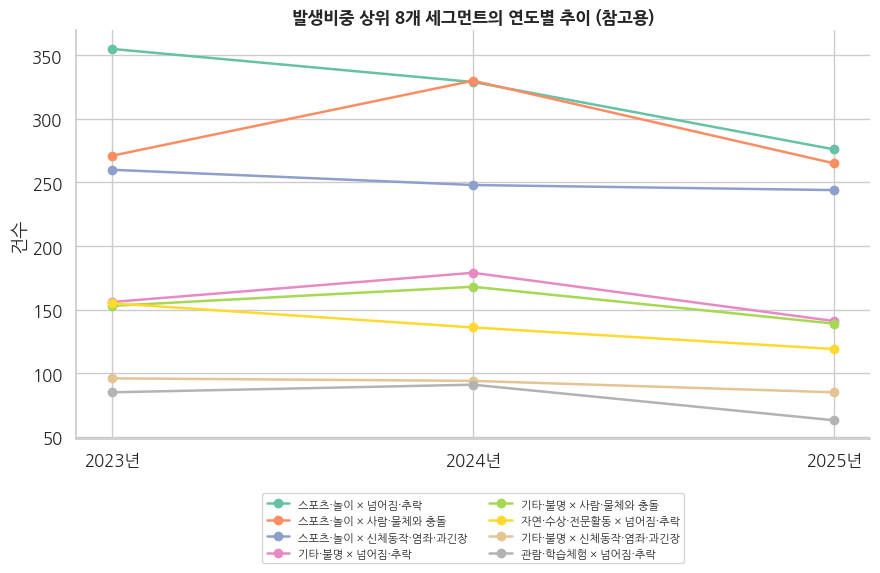

In [ ]:
# [참고] 연도별 추이 그래프 TOP 8
top8 = segment_main.nlargest(8, '발생비중')

fig, ax = plt.subplots(figsize=(9, 6))
years = ['2023년', '2024년', '2025년']

for _, row in top8.iterrows():
    ax.plot(years, row[years].values, marker='o', label=row['세그먼트'], linewidth=1.8)

ax.set_ylabel('건수')
ax.set_title('발생비중 상위 8개 세그먼트의 연도별 추이 (참고용)', fontsize=12, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### **조건부 고비용점수** (미정)

- 

### **순위역전지수** (미정)

-  

In [ ]:
segment_main['순위역전지수'] = (segment_main['조건부고비용점수'] - segment_main['사고건수_백분위']).round(1)

### 계산 결과

In [ ]:
# 과소평가된 위험 (순위역전지수 상위 10)
display(segment_main[['세그먼트', '반복부담점수', '조건부고비용점수', '순위역전지수']].sort_values('순위역전지수', ascending=False).head(10))

,세그먼트,반복부담점수,조건부고비용점수,순위역전지수
26,자연·수상·전문활동 × 기타·불명,8.1,87.096774,79.0
25,식사·숙박·생활 × 온도·화학·환경노출,17.7,83.870968,66.1
22,식사·숙박·생활 × 넘어짐·추락,48.4,91.935484,43.5
6,교통수단 이동·승하차 × 사람·물체와 충돌,38.7,77.419355,38.7
4,관람·학습체험 × 온도·화학·환경노출,3.2,27.419355,24.2
30,자연·수상·전문활동 × 신체동작·염좌·과긴장,74.2,96.774194,22.6
2,관람·학습체험 × 사람·물체와 충돌,51.6,74.193548,22.6
27,자연·수상·전문활동 × 끼임·베임·찔림,8.1,27.419355,19.4
20,식사·숙박·생활 × 기타·불명,12.9,27.419355,14.5
8,기타·불명 × 기타·불명,71.0,80.645161,9.7


In [ ]:
# 해석 불가능한 세그먼트 별도 표시 (기타·불명 × 기타·불명)
segment_main['해석가능'] = ~segment_main['세그먼트'].str.contains('기타·불명 × 기타·불명')

display(
    segment_main[segment_main['해석가능']]
    .sort_values('순위역전지수', ascending=False)
    .head(10)[['세그먼트', '반복부담점수', '조건부고비용점수', '순위역전지수']]
)

,세그먼트,반복부담점수,조건부고비용점수,순위역전지수
26,자연·수상·전문활동 × 기타·불명,8.1,87.096774,79.0
25,식사·숙박·생활 × 온도·화학·환경노출,17.7,83.870968,66.1
22,식사·숙박·생활 × 넘어짐·추락,48.4,91.935484,43.5
6,교통수단 이동·승하차 × 사람·물체와 충돌,38.7,77.419355,38.7
4,관람·학습체험 × 온도·화학·환경노출,3.2,27.419355,24.2
30,자연·수상·전문활동 × 신체동작·염좌·과긴장,74.2,96.774194,22.6
2,관람·학습체험 × 사람·물체와 충돌,51.6,74.193548,22.6
27,자연·수상·전문활동 × 끼임·베임·찔림,8.1,27.419355,19.4
20,식사·숙박·생활 × 기타·불명,12.9,27.419355,14.5
9,기타·불명 × 끼임·베임·찔림,61.3,70.967742,9.7


In [ ]:
# 과대평가된 위험 (순위역전지수 하위 10)
display(
    segment_main[segment_main['해석가능']]
    .sort_values('순위역전지수')
    .head(10)[['세그먼트', '반복부담점수', '조건부고비용점수', '순위역전지수']]
)

,세그먼트,반복부담점수,조건부고비용점수,순위역전지수
12,기타·불명 × 신체동작·염좌·과긴장,80.6,27.419355,-53.2
1,관람·학습체험 × 넘어짐·추락,77.4,27.419355,-50.0
18,스포츠·놀이 × 사람·물체와 충돌,96.8,54.838710,-41.9
16,스포츠·놀이 × 끼임·베임·찔림,67.7,27.419355,-40.3
19,스포츠·놀이 × 신체동작·염좌·과긴장,93.5,61.290323,-32.3
17,스포츠·놀이 × 넘어짐·추락,100.0,67.741935,-32.3
29,자연·수상·전문활동 × 사람·물체와 충돌,58.1,27.419355,-30.6
11,기타·불명 × 사람·물체와 충돌,87.1,58.064516,-29.0
23,식사·숙박·생활 × 사람·물체와 충돌,54.8,27.419355,-27.4
3,관람·학습체험 × 신체동작·염좌·과긴장,45.2,27.419355,-17.7


## 이중위험지도

## 통제가능성 매핑

- 교사 지도 중심형: 교사의 사전교육·질서유지·학생행동 관리가 핵심
- 공동통제형: 교사 지도와 외부기관의 지원이 함께 필요
- 시스템 지원 의존형: 전문인력·시설·운송·장비가 핵심